In [1]:
import pandas as pd

df = pd.read_csv("data/raw/store_performance.csv")

df.head()

,date,hour,employee_id,employee_name,hours_worked,customer_traffic,transactions,sales_revenue,sales_target,product_category,units_sold,accessory_sales,customer_rating,wait_time_minutes
0,2026-01-01,9,E002,Noah,1,5,2,255.29,300.0,Internet,6,0,4.3,3.9
1,2026-01-01,9,E006,Arjun,1,5,2,258.22,300.0,Mobile,6,0,4.1,3.4
2,2026-01-01,9,E005,Zara,1,6,2,355.22,300.0,Accessories,5,0,4.6,5.8
3,2026-01-01,10,E003,Mia,1,7,3,380.10,300.0,Accessories,7,0,4.1,4.8
4,2026-01-01,10,E005,Zara,1,7,2,513.21,300.0,Mobile,2,0,4.3,3.2


In [3]:
df.shape

(1606, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1606 non-null   object 
 1   hour               1606 non-null   int64  
 2   employee_id        1606 non-null   object 
 3   employee_name      1606 non-null   object 
 4   hours_worked       1606 non-null   int64  
 5   customer_traffic   1606 non-null   int64  
 6   transactions       1606 non-null   int64  
 7   sales_revenue      1606 non-null   float64
 8   sales_target       1606 non-null   float64
 9   product_category   1606 non-null   object 
 10  units_sold         1606 non-null   int64  
 11  accessory_sales    1606 non-null   int64  
 12  customer_rating    1606 non-null   float64
 13  wait_time_minutes  1606 non-null   float64
dtypes: float64(4), int64(6), object(4)
memory usage: 175.8+ KB


In [7]:
df.isnull().sum()

date                 0
hour                 0
employee_id          0
employee_name        0
hours_worked         0
customer_traffic     0
transactions         0
sales_revenue        0
sales_target         0
product_category     0
units_sold           0
accessory_sales      0
customer_rating      0
wait_time_minutes    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [11]:
print("Transactions greater than customer traffic:",
      (df["transactions"] > df["customer_traffic"]).sum())

print("Negative sales:",
      (df["sales_revenue"] < 0).sum())

print("Invalid customer ratings:",
      ((df["customer_rating"] < 1) | (df["customer_rating"] > 5)).sum())

print("Negative wait times:",
      (df["wait_time_minutes"] < 0).sum())

Transactions greater than customer traffic: 0
Negative sales: 0
Invalid customer ratings: 0
Negative wait times: 0


In [13]:
df["conversion_rate"] = (
    df["transactions"] / df["customer_traffic"]
) * 100

df[[
    "customer_traffic",
    "transactions",
    "conversion_rate"
]].head(10)

,customer_traffic,transactions,conversion_rate
0,5,2,40.000000
1,5,2,40.000000
2,6,2,33.333333
3,7,3,42.857143
4,7,2,28.571429
5,8,4,50.000000
6,5,2,40.000000
7,2,0,0.000000
8,3,1,33.333333
9,3,0,0.000000


In [15]:
df["target_achievement_pct"] = (
    df["sales_revenue"] / df["sales_target"]
) * 100

df[[
    "sales_revenue",
    "sales_target",
    "target_achievement_pct"
]].head(10)

,sales_revenue,sales_target,target_achievement_pct
0,255.29,300.0,85.096667
1,258.22,300.0,86.073333
2,355.22,300.0,118.406667
3,380.10,300.0,126.700000
4,513.21,300.0,171.070000
5,491.70,300.0,163.900000
6,354.86,225.0,157.715556
7,0.00,225.0,0.000000
8,272.91,225.0,121.293333
9,0.00,225.0,0.000000


In [17]:
df["average_transaction_value"] = (
    df["sales_revenue"] /
    df["transactions"].replace(0, pd.NA)
)

df[[
    "sales_revenue",
    "transactions",
    "average_transaction_value"
]].head(10)

,sales_revenue,transactions,average_transaction_value
0,255.29,2,127.645
1,258.22,2,129.11
2,355.22,2,177.61
3,380.10,3,126.7
4,513.21,2,256.605
5,491.70,4,122.925
6,354.86,2,177.43
7,0.00,0,<NA>
8,272.91,1,272.91
9,0.00,0,<NA>


In [19]:
df[[
    "conversion_rate",
    "target_achievement_pct",
    "average_transaction_value"
]].describe()

,conversion_rate,target_achievement_pct
count,1606.000000,1606.000000
mean,31.777308,124.577289
std,13.563663,75.557502
min,0.000000,0.000000
25%,25.000000,73.572593
50%,33.333333,115.483457
75%,40.000000,169.981481
max,66.666667,522.858667


In [21]:
average_target = df["target_achievement_pct"].mean()

print(f"Average Target Achievement: {average_target:.2f}%")

Average Target Achievement: 124.58%


In [23]:
below_target = (df["target_achievement_pct"] < 100).sum()
above_target = (df["target_achievement_pct"] >= 100).sum()

print("Records below target:", below_target)
print("Records meeting or exceeding target:", above_target)

Records below target: 658
Records meeting or exceeding target: 948


In [25]:
hourly_performance = df.groupby("hour").agg({
    "sales_revenue": "sum",
    "sales_target": "sum",
    "customer_traffic": "sum",
    "transactions": "sum"
}).reset_index()

hourly_performance["target_achievement_pct"] = (
    hourly_performance["sales_revenue"] /
    hourly_performance["sales_target"]
) * 100

hourly_performance

,hour,sales_revenue,sales_target,customer_traffic,transactions,target_achievement_pct
0,9,68653.00,58050.00,982,316,118.265289
1,10,73426.47,58050.00,1047,353,126.488320
2,11,72273.85,58050.00,1036,342,124.502756
3,12,108847.81,78367.62,1404,517,138.893857
4,13,106398.97,78367.64,1454,511,135.769011
5,14,68698.17,58050.00,997,339,118.343101
6,15,66959.45,58050.00,1000,323,115.347890
7,16,114755.67,78367.64,1453,521,146.432469
8,17,107717.99,78367.65,1418,518,137.452112


In [27]:
staffing = df.groupby(["date", "hour"])["employee_id"].nunique().reset_index()

staffing.rename(
    columns={"employee_id": "staff_on_floor"},
    inplace=True
)

staffing.head()

,date,hour,staff_on_floor
0,2026-01-01,9,3
1,2026-01-01,10,3
2,2026-01-01,11,4
3,2026-01-01,12,2
4,2026-01-01,13,4


In [29]:
df = df.merge(
    staffing,
    on=["date", "hour"],
    how="left"
)

df[[
    "date",
    "hour",
    "employee_id",
    "customer_traffic",
    "staff_on_floor"
]].head(10)

,date,hour,employee_id,customer_traffic,staff_on_floor
0,2026-01-01,9,E002,5,3
1,2026-01-01,9,E006,5,3
2,2026-01-01,9,E005,6,3
3,2026-01-01,10,E003,7,3
4,2026-01-01,10,E005,7,3
5,2026-01-01,10,E006,8,3
6,2026-01-01,11,E006,5,4
7,2026-01-01,11,E001,2,4
8,2026-01-01,11,E002,3,4
9,2026-01-01,11,E003,3,4


In [31]:
df["staffing_pressure"] = (
    df["customer_traffic"] / df["staff_on_floor"]
)

df[[
    "customer_traffic",
    "staff_on_floor",
    "staffing_pressure",
    "wait_time_minutes"
]].head(10)

,customer_traffic,staff_on_floor,staffing_pressure,wait_time_minutes
0,5,3,1.666667,3.9
1,5,3,1.666667,3.4
2,6,3,2.000000,5.8
3,7,3,2.333333,4.8
4,7,3,2.333333,3.2
5,8,3,2.666667,3.6
6,5,4,1.250000,5.3
7,2,4,0.500000,2.8
8,3,4,0.750000,5.0
9,3,4,0.750000,3.1


In [33]:
correlation = df["staffing_pressure"].corr(
    df["wait_time_minutes"]
)

print(f"Correlation: {correlation:.2f}")

Correlation: 0.39


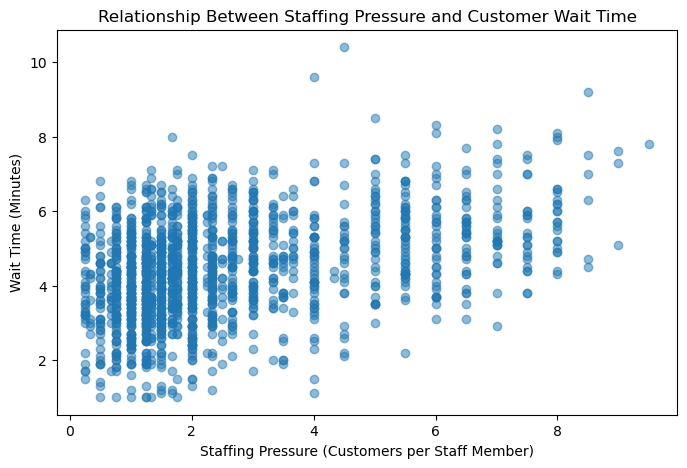

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["staffing_pressure"],
    df["wait_time_minutes"],
    alpha=0.5
)

plt.xlabel("Staffing Pressure (Customers per Staff Member)")
plt.ylabel("Wait Time (Minutes)")
plt.title("Relationship Between Staffing Pressure and Customer Wait Time")

plt.show()

In [37]:
pressure_threshold = df["staffing_pressure"].median()
wait_threshold = df["wait_time_minutes"].median()

print(f"Typical staffing pressure: {pressure_threshold:.2f}")
print(f"Typical wait time: {wait_threshold:.2f} minutes")

Typical staffing pressure: 1.75
Typical wait time: 4.40 minutes
